In [1]:
# Perform the water and energy balance analyses for an AM3 run.
import xarray
import iris
import numpy
import pathlib
import warnings
import matplotlib.pyplot as plt
import cartopy.crs

In [2]:
def select_fields(ds, fields):
    return xarray.Dataset({v:ds[v] for v in fields})
    
def load_outputs(run_dir, fields, stream='m', years=None):
    """
    Load the outputs from the specified run directory, with the only the given fields loaded from the NetCDF output.
    Only loads the specific stream.
    If years are specified, only loads data within that year range, otherwise it loads all outputs.
    """

    # First load in the NetCDF outputs
    output_dir = run_dir / 'share/data/History_Data/netCDF'
    nc_files = []
    if years is not None:
        for year in years:
            files_for_year = output_dir.glob(f'am3a.p{stream}{year}*')
    else:
        nc_files = output_dir.glob(f'am3a.p{stream}*')

    time_coder = xarray.coders.CFDatetimeCoder(use_cftime=True)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        ds = xarray.open_mfdataset(list(nc_files), combine='by_coords', decode_times=time_coder, preprocess=lambda ds: select_fields(ds, fields), parallel=False)

    ds = ds.rename_dims({'pseudo_level_2': 'tile'})
    return ds
    
def instantaneous_callback(cube, field, filename):
    if cube.cell_methods:
        raise iris.exceptions.IgnoreCubeException
        
def load_restarts(run_dir, fields, years=None):
    """
    Load the restarts from the specified run directory, with the given fields loaded from the restarts.
    If years are specified, takes the first and last restart from that year range. Otherwise takes the absolute first and last restart.
    """
    
    # if years is not None, check for the first restart from the first year
    if years is not None:
        init_rst_path = run_dir / f'share/data/History_Data/am3a.da{year[0]}0101_00'
        if not init_rst_path.is_file():
            # No rst for the start of that year- must be the base restart
            init_rst_path = run_dir / f'share/data/am3a.ainitial'

        end_rst_path = run_dir / f'share/data/History_Data/am3a.da{year[-1]}0101_00'
    else:
        init_rst_path = run_dir / f'share/data/am3a.ainitial'

        # The end restart should be the the final entry of a glob searching for year end restarts
        rst_dir = run_dir / 'share/data/History_Data'
        year_end_rsts = sorted(list(rst_dir.glob('am3a.da*0101_00')))
        end_rst_path = year_end_rsts[-1]

    dim_mapping = {'latitude': 'lat', 'longitude': 'lon', 'pseudo_level': 'tile'}
    init_rst = xarray.Dataset()
    end_rst = xarray.Dataset()

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        for field in fields:
            init_rst[field] = xarray.DataArray.from_iris(iris.load_cube(init_rst_path, callback=instantaneous_callback, constraint=iris.AttributeConstraint(STASH=field))).rename(dim_mapping)
            end_rst[field] = xarray.DataArray.from_iris(iris.load_cube(end_rst_path, callback=instantaneous_callback, constraint=iris.AttributeConstraint(STASH=field))).rename(dim_mapping)
        
    return init_rst, end_rst

In [3]:
def create_mask(rst):
    """
    Use the given restart file to create a mask which masks all grid cells that are not 100% land, as well as any grid cells that contain any lake or ice fraction.
    """

    land_fractions = rst['m01s00i505']
    tile_fractions = rst['m01s00i216']

    mask = xarray.where(land_fractions >= 1.0, 0, numpy.nan) + \
            xarray.where(tile_fractions[15] > 0.0, numpy.nan, 0) + \
            xarray.where(tile_fractions[16] > 0.0, numpy.nan, 0)
    return mask

In [4]:
def compute_area(output):
    """
    Compute the cell areas using the lat/lon bnds on the output dataset.
    """
    R_earth = 6371e3

    lat_rad = numpy.radians(output['lat_bnds'])
    lon_rad = numpy.radians(output['lon_bnds'])
    dlat = numpy.sin(lat_rad.isel(bnds=1, time=0)) - numpy.sin(lat_rad.isel(bnds=0, time=0))
    dlon = lon_rad.isel(bnds=1, time=0) - lon_rad.isel(bnds=0, time=0)

    area = R_earth ** 2 * dlat * dlon
    return area

In [5]:
def annual_mean(ds):
    """ Properly month length weighted annual mean of a DataArray"""
    if not ds.time.dt.month[0] == 1:
        raise ValueError("Data does not start with January")
    if not ds.time.dt.month[1] == 2:
        raise ValueError("Non-monthly data")
    # Process only complete years
    nmon = 12*(len(ds.time)//12)
    month_length = ds.time.dt.days_in_month[:nmon]
    weights = month_length.groupby('time.year') / month_length.groupby('time.year').sum()
    ann_mean = (ds[:nmon]*weights).groupby('time.year').sum(dim='time',min_count=1)
    return ann_mean

In [6]:
def water_balance(output, init_rst, end_rst):
    """
    Compute the net water balance using the run outputs as well as the starting and end states.
    Returns the net change in water storage, and the average water flux in mm m-2.
    """

    # Start with net water contained in the soil, snow and canopy
    total_initial_soil_moisture = init_rst['m01s00i009'].sum('depth')
    total_end_soil_moisture = end_rst['m01s00i009'].sum('depth')

    total_initial_snow_mass = init_rst['m01s00i023']
    total_end_snow_mass = end_rst['m01s00i023']

    total_initial_canopy_water = init_rst['m01s00i022']
    total_end_canopy_water = end_rst['m01s00i022']

    #total_water_change = (total_end_soil_moisture + total_end_snow_mass + total_end_canopy_water) - (total_initial_soil_moisture + total_initial_snow_mass + total_initial_canopy_water)
    total_water_change = (total_end_soil_moisture + total_end_snow_mass) - (total_initial_soil_moisture + total_initial_snow_mass)

    # Convert to per second
    ndays = (output.time_bnds[-1, -1] - output.time_bnds[0, 0]).values.item().days
    water_rate_of_change = total_water_change / (86400 * ndays)

    # Now compute the net flux of water to the land
    precip = output['fld_s05i216']
    total_evap = output['fld_s03i223']
    surf_runoff = output['fld_s08i234']
    subsurf_runoff = output['fld_s08i235']

    water_flux = annual_mean(precip - total_evap - surf_runoff - subsurf_runoff).mean('year')

    return water_rate_of_change, water_flux

In [7]:
def energy_balance(output, init_rst, end_rst):
    """
    Compute the net energy balance using the run outputs as well as the starting and end states.
    Returns the net change in energy storage, and the average energy flux in W m-2.
    """

    # Start with energy contained in the soil
    # Soil properties are constant everywhere
    """
    The energy strorage in soil/snow is yet to be implemented.
    It should be, in pseudo-code:
    sum_over_soi_layers(soil_temp * (soil_mass * soil_spec_heat + water_mass * water_spec_heat + ice_mass * ice_spec_heat)) +
    sum_over_snow_layers(snow_temp * snow_mass * snow_spec_heat)

    However, JULES does not use the density at all- everything is in volumetric terms, while CABLE's are in mass terms.
    We might be able to rely on the JULES soil quantities and use their volumetric heat capacity?
    
    soil_density = 1650.0    # kg m-3
    soil_spec_heat = 850.0   # J kg-1 K-1

    # water/ice properties
    water_density = 1000.0
    ice_density = 921.0
    water_spec_heat = 4218.0
    ice_spec_heat = 2100.0
    """
    
    upward_shortwave = output['fld_s03i217']
    upward_longwave = output['fld_s03i234']
    snow_melt_heat_flux = output['fld_s03i258']
    net_down_on_tiles = output['fld_s03i314']

    # Take the tile fractions from the restart
    tile_fractions = init_rst['m01s00i216']

    # Sum net radiation over tiles
    total_net_down = (output['fld_s03i314'] * tile_fractions).sum('tile')

    net_energy = annual_mean(total_net_down - upward_shortwave - upward_longwave - snow_melt_heat_flux).mean('year')

    return net_energy

In [15]:
# Coordinate fields
coord_fields = ['lon', 'lat', 'time', 'lon_bnds', 'lat_bnds', 'time_bnds']

# precipitation, total_evaporation, surface runoff, subsurface runoff
water_flux_fields = ['fld_s05i216', 'fld_s03i223', 'fld_s08i234', 'fld_s08i235']
# net upward shortwave, net upward longwave, snow melt heat flux, net downward on tiles
energy_fields = ['fld_s03i217', 'fld_s03i234', 'fld_s03i258', 'fld_s03i314']

# soil moisture content, snow mass, canopy moisture
water_storage_rst = ['m01s00i009', 'm01s00i023', 'm01s00i022']
# land fractions, land cover fractions
land_fractions = ['m01s00i505', 'm01s00i216']

expt = 'access-am3-dev-n96e-add-netrad'
branch = 'AM3-dev branch'
res = load_outputs(pathlib.Path(f'/scratch/tm70/lw5085/cylc-run/{expt}'), coord_fields + water_flux_fields + energy_fields)
irst, erst = load_restarts(pathlib.Path(f'/scratch/tm70/lw5085/cylc-run/{expt}'), water_storage_rst + land_fractions)

[PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19830101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19840101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19850101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19860101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19870101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19880101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19890101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e-add-netrad/share/data/History_Data/am3a.da19900101_00'), PosixPath('/scratch/tm70/lw5085/cylc-run/access-am3-dev

In [16]:
mask = create_mask(irst)

In [17]:
area = compute_area(res)

In [22]:
water_storage_change, water_net_flux = water_balance(res, irst, erst)

In [23]:
net_energy = energy_balance(res, irst, erst)

/g/data/xp65/public/apps/med_conda/envs/analysis3_edge-25.08/lib/python3.11/site-packages/dask/array/core.py:5003: PerformanceWarning: Increasing number of chunks by factor of 17
  result = blockwise(


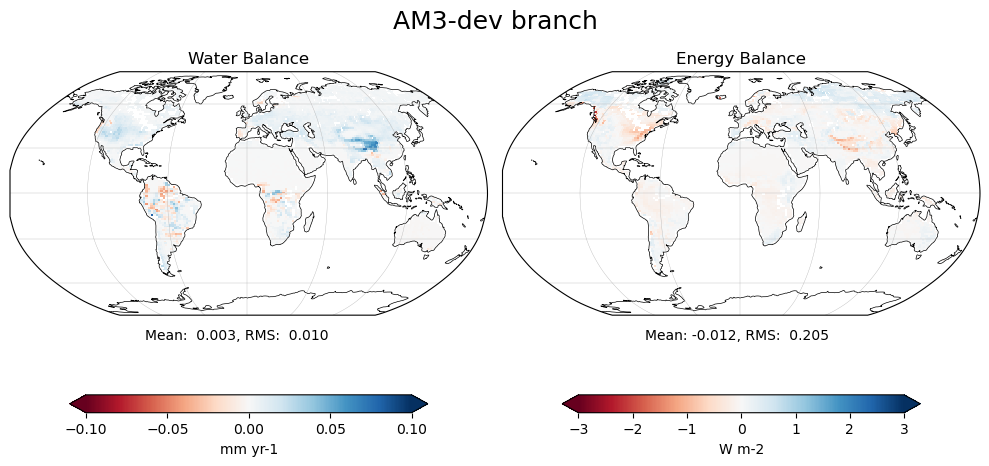

In [24]:
fig, (ax_water, ax_energy) = plt.subplots(1, 2, figsize=(10, 6), subplot_kw=dict(projection=cartopy.crs.Robinson()))

ax_water.coastlines(resolution='110m',linewidth=0.5)
ax_water.gridlines(draw_labels=False,linewidth=0.25)

ax_energy.coastlines(resolution='110m',linewidth=0.5)
ax_energy.gridlines(draw_labels=False,linewidth=0.25)

water_diff = 365*86400*(water_net_flux - water_storage_change) + mask
water_p = water_diff.plot(ax=ax_water, transform=cartopy.crs.PlateCarree(), add_colorbar=False, cmap='RdBu', vmax=0.1)
plt.colorbar(water_p, shrink=0.75, orientation='horizontal', extend='both', label='mm yr-1')
water_mean = (water_diff * area).sum() / (area + mask).sum()
water_rms = ((water_diff * water_diff * area).sum() / (area + mask).sum())**0.5
fig.text(0.15, 0.25, f'Mean: {float(water_mean.data):6.3f}, RMS: {float(water_rms.data):6.3f}')
ax_water.set_title('Water Balance')
energy_diff = net_energy + mask
energy_p = energy_diff.plot(ax=ax_energy, transform=cartopy.crs.PlateCarree(), add_colorbar=False, cmap='RdBu', vmax=3)
plt.colorbar(energy_p, shrink=0.75, orientation='horizontal', extend='both', label='W m-2')
energy_mean = (energy_diff * area).sum() / (area + mask).sum()
energy_rms = ((energy_diff * energy_diff * area).sum() / (area + mask).sum())**0.5
fig.text(0.65, 0.25, f'Mean: {float(energy_mean.data):6.3f}, RMS: {float(energy_rms.data):6.3f}')
ax_energy.set_title('Energy Balance')
fig.suptitle(f'{branch}', y=0.8, size=18)
plt.tight_layout()
plt.savefig(f'{branch}-10yrs.png')